q1

x1----4.0
x2----2.0


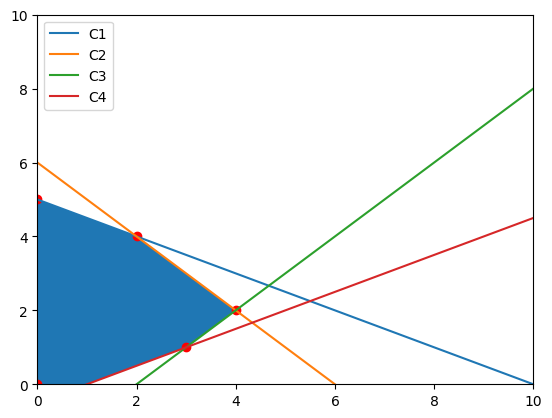

In [13]:
from pulp import *
import numpy as np
import matplotlib.pyplot as plt

prob=LpProblem('lpp',LpMaximize)

x1=LpVariable('x1',0)
x2=LpVariable('x2',0)

prob +=2*x1+x2,"objective function"
prob +=x1+2*x2<=10," contraint 1"
prob +=x1+x2<=6,"constraint 2"
prob +=x1-x2<=2,"constraint 3"
prob +=x1-2*x2<=1,"contraint 4"

prob.solve()
for v in prob.variables():
    print(f"{v.name}----{v.varValue}")

x=np.linspace(0,10,100)
y1=(10-x)/2
y2=6-x
y3=x-2
y4=(x-1)/2
x_lower=np.maximum.reduce([np.zeros_like(x),y3,y4])
x_upper=np.minimum.reduce([y1,y2])

plt.plot(x,(10-x)/2,label='C1')
plt.plot(x,(6-x),label='C2')
plt.plot(x,(x-2),label='C3')
plt.plot(x,(x-1)/2,label='C4')
plt.fill_between(x,x_lower,x_upper,where=(x_upper>=x_lower))
plt.scatter([0,2,4,3,0],[0,4,2,1,5],marker='o',color='red')
plt.legend()
plt.xlim([0,10])

plt.ylim([0,10])
plt.show()


x1----4.0
x2----2.0


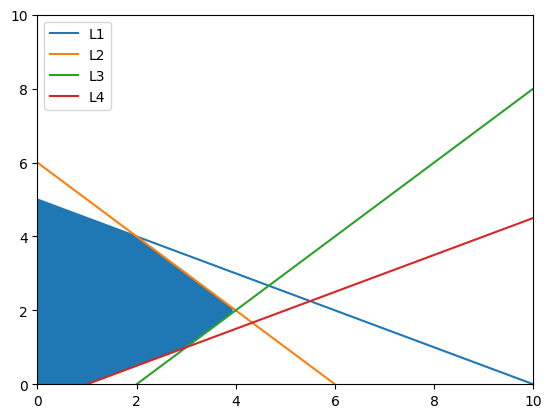

In [17]:
from pulp import *
import numpy as np 
import matplotlib.pyplot as plt
x1=LpVariable('x1')
x2=LpVariable('x2')
prob=LpProblem('lpp',LpMaximize)
prob+=2*x1+x2,'objective function'
prob+=x1+2*x2<=10,'constraint 1'
prob+=x1+x2<=6,'constraint 2'
prob+=x1-x2<=2,'constraint 3'
prob+=x1-2*x2<=1,'constriant 4'

prob.solve()
for v in prob.variables():
  print(f"{v.name}----{v.varValue}")

x=np.linspace(0,10,100)
y1=(10-x)/2
y2=6-x
y4=(x-1)/2
y3=x-2

x1=np.maximum.reduce([np.zeros_like(x),y3,y4])
x2=np.minimum.reduce([y1,y2])

plt.fill_between(x,x1,x2,where=x1<=x2)
plt.plot(x,y1,label='L1')
plt.plot(x,y2,label='L2')
plt.plot(x,y3,label='L3')
plt.plot(x,y4,label='L4')
plt.xlim([0,10])
plt.ylim([0,10])

plt.legend()
plt.show()

In [ ]:
import sympy as sp
x,y=sp.symbols('x y')
L1=x+2*y-10
L2=x+y-6
L3=x-y-2
L4=x-2*y-1
sol1=sp.solve((L1,L2),(x,y))
sol2=sp.solve((L3,L2),(x,y))
sol3=sp.solve((L3,L4),(x,y))
print(sol1)
print(sol2)
print(sol3)


{x: 2, y: 4}
{x: 4, y: 2}
{x: 3, y: 1}


q2

In [ ]:
import numpy as np
A=np.array([
    [3,4,8,6,1,0,0],
    [2,2,7,5,0,1,0],
    [6,4,7,4,0,0,1]
],dtype=float)
b=np.array([800,200,700],dtype=float)
c=np.array([45,40,85,65,0,0,0],dtype=float)
z=np.zeros(A.shape[0],dtype=float)
x_b=np.zeros(A.shape[0],dtype=float)
c_b=np.zeros(A.shape[0],dtype=float)
zj_cj=np.zeros(A.shape[1],dtype=float)

iter=0
max_iter=50
basic_var=np.array([4,5,6])
c_b=c[basic_var]
while max_iter>iter:
    for j in range(A.shape[1]): 
        zj_cj[j]=np.dot(c_b,A[:,j])-c[j]
    index=np.argmin(zj_cj)
    min_val=np.min(zj_cj)
    if min_val<0:
        ratio=np.zeros(A.shape[0],dtype=float)
        for k in range(A.shape[0]):
            ratio[k]=b[k]/A[k,index]
            if ratio[k]<0:
                ratio[k]=float(np.inf)
        min_index=np.argmin(ratio)
        pivot=A[min_index,index]
        A[min_index,:]=A[min_index,:]/pivot
        b[min_index]=b[min_index]/pivot
        basic_var[min_index]=index
        c_b=c[basic_var]
        for k in range(A.shape[0]):

            if k!=min_index:
                A[k,:]=A[k,:]-A[k,min_index]*A[min_index,:]
                b[k]=b[k]-A[k,min_index]*b[min_index]
    else:
        print(np.dot(c_b,b))
        break
    iter+=1






[ 0.   5.  72.5 47.5  0.  22.5  0. ]
4500.000000000001


q3
z=12A+15B+14C/
A+B+C<=100/
0.02A+0.04B+0.03C<=0.03(A+B+C)
=>-0.01A+0.01B+0C<=0
3A+2B+5c<=3(A+B+C)
=>-B+2C<=0

In [38]:
import numpy as np
A=np.array([
    [1,1,1,1,0,0],
    [-0.01,0.01,0,0,1,0],
    [0,-1,2,0,0,1]
],dtype=float)
b=np.array([100,0,0],dtype=float)
c=np.array([12,15,14,0,0,0],dtype=float)
basic_var=np.array([3,4,5],dtype=int)
c_b=np.zeros(A.shape[0],dtype=float)
c_b=c[basic_var]
zj_cj=np.zeros(A.shape[1],dtype=float)

iter=0
max_iter=50

while max_iter>iter:
      
    for j in range(A.shape[1]):
        zj_cj[j]=np.dot(c_b,A[:,j])-c[j]


    index=np.argmin(zj_cj)
    min_val=np.min(zj_cj)
    if min_val<0:
        ratio=np.zeros(A.shape[0])
        for i in range(A.shape[0]):
                if A[i,index]>0:
                  ratio[i]=b[i]/A[i,index]
                else:
                  ratio[i]=float(np.inf)
        min_ratio=np.min(ratio)
        min_index=np.argmin(ratio)
        basic_var[min_index]=index
        c_b=c[basic_var]
        pivot=A[min_index,index]
        A[min_index,:]=A[min_index,:]/pivot
        b[min_index]=b[min_index]/pivot

        for k in range(A.shape[0]):
            factor=A[k,index]
            if k!=min_index:
                A[k,:]=A[k,:]-factor*A[min_index,:]
                b[k]=b[k]-factor*b[min_index]
    else:
        print(zj_cj)
        print(np.dot(c_b,b))
        break
    iter+=1


[  0.    0.    0.   13.6 160.    0.2]
1360.0


In [85]:
A=np.array([
    [1,1,1,1,0,0],
    [0,-0.01,0.01,0,1,0],
    [0,-1,2,0,0,1]
],dtype=float)
b=np.array([100,0,0],dtype=float)
c=np.array([12,15,14,0,0,0])

basic_var=np.array([3,4,5],dtype=int)
zj_cj=np.zeros(A.shape[1],dtype=float)
c_b=np.zeros(A.shape[0],dtype=float)
c_b=c[basic_var]
iter=0
max_iter=50
while max_iter>iter:
    for j in range(A.shape[1]):
        zj_cj[j]=np.dot(c_b,A[:,j])-c[j]
    min_val=np.min(zj_cj)
    index=np.argmin(zj_cj)
    if min_val<0:
        ratio = np.full(A.shape[0], np.inf)

        for i in range(A.shape[0]):
            if A[i,index] > 0:
                ratio[i] = b[i] / A[i,index]
        min_index=np.argmin(ratio)
        basic_var[min_index]=index
        c_b=c[basic_var]
        pivot=A[min_index,index]
        b[min_index]=b[min_index]/pivot
        A[min_index,:]=A[min_index,:]/pivot
        
        for k in range(A.shape[0]):
              if k!=min_index:
                factor = A[k,index]
                A[k,:]=A[k,:]-factor*A[min_index,:]
                b[k]=b[k]-factor*b[min_index]
    else:
        print(zj_cj)
        print(np.dot(c_b,b))
        break
    iter+=1

[ 3.  0.  1. 15.  0.  0.]
1500.0


In [41]:
from scipy.optimize import linprog
A=[
[1,1,1],
[-0.01,0.01,0],
[0,-1,2]
]
b=[100,0,0]
c=[-12,-15,-14]
x_bounds=[(0,None)]*3
res=linprog(c,A_ub=A,b_ub=b,bounds=x_bounds,method='simplex')
if res.success:
    print(-res.fun)
    print(res.x)

1360.0
[40. 40. 20.]


C:\Users\Sifat\AppData\Local\Temp\ipykernel_12444\1584115110.py:10: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  res=linprog(c,A_ub=A,b_ub=b,bounds=x_bounds,method='simplex')


In [46]:
M=1000
A=np.array([
    [200,100,-1,0,0,1,0,0],
    [1,2,0,-1,0,0,1,0],
    [40,40,0,0,-1,0,0,1]
],dtype=float)
b=np.array([4000,50,1400],dtype=float)
c=np.array([-4,-3,0,0,0,-M,-M,-M],dtype=float)
basic_var=np.array([5,6,7],dtype=int)
c_b=np.zeros(A.shape[0],dtype=float)
c_b=c[basic_var]
zj_cj=np.zeros(A.shape[1],dtype=float)

iter=0
max_iter=50

while max_iter>iter:
      
    for j in range(A.shape[1]):
        zj_cj[j]=np.dot(c_b,A[:,j])-c[j]


    index=np.argmin(zj_cj)
    min_val=np.min(zj_cj)
    if min_val<0:
        ratio=np.zeros(A.shape[0])
        for i in range(A.shape[0]):
                if A[i,index]>0:
                  ratio[i]=b[i]/A[i,index]
                else:
                  ratio[i]=float(np.inf)
        min_ratio=np.min(ratio)
        min_index=np.argmin(ratio)
        basic_var[min_index]=index
        c_b=c[basic_var]
        pivot=A[min_index,index]
        A[min_index,:]=A[min_index,:]/pivot
        b[min_index]=b[min_index]/pivot

        for k in range(A.shape[0]):
            factor=A[k,index]
            if k!=min_index:
                A[k,:]=A[k,:]-factor*A[min_index,:]
                b[k]=b[k]-factor*b[min_index]
    else:
        print(zj_cj)
        print(-np.dot(c_b,b))
        print('=====solution=====')
        print(b)
        break
    iter+=1


[0.0000e+00 0.0000e+00 1.0000e-02 0.0000e+00 5.0000e-02 9.9999e+02
 1.0000e+03 9.9995e+02]
110.0
=====solution=====
[ 5. 30. 15.]


In [ ]:
import numpy as np

M = 1000

A = np.array([
    [2, 1, -1, 0, 0, 1, 0, 0],
    [1, 2, 0, -1, 0, 0, 1, 0],
    [1, 1, 0, 0, -1, 0, 0, 1]
], dtype=float)

b = np.array([40, 50, 35], dtype=float)

# Coefficients for Maximization (-Z = -4x1 - 3x2 - 0s1 - 0s2 - 0s3 - MA1 - MA2 - MA3)
c = np.array([-4, -3, 0, 0, 0, -M, -M, -M], dtype=float)

# Initial basic variables: A1, A2, A3 (Indices 5, 6, 7)
basic_var = np.array([5, 6, 7], dtype=int)
zj_cj = np.zeros(A.shape[1], dtype=float)
c_b = c[basic_var]

# Iteration loop
iter_count = 0
while iter_count < 50:
    for j in range(A.shape[1]):
        zj_cj[j] = np.dot(c_b, A[:, j]) - c[j]
    
    min_val = np.min(zj_cj)
    index = np.argmin(zj_cj)
    
    if min_val < -1e-9: # Optimality condition
        ratio = np.full(A.shape[0], np.inf)
        for i in range(A.shape[0]):
            if A[i, index] > 0:
                ratio[i] = b[i] / A[i, index]
        
        min_index = np.argmin(ratio)
        basic_var[min_index] = index
        c_b = c[basic_var]
        
        # Row operations (Pivoting)
        pivot = A[min_index, index]
        b[min_index] /= pivot
        A[min_index, :] /= pivot
        for k in range(A.shape[0]):
            if k != min_index:
                factor = A[k, index]
                A[k, :] -= factor * A[min_index, :]
                b[k] -= factor * b[min_index]
    else:
        break
    iter_count += 1

print(f"Optimal Units: x1={b[np.where(basic_var==0)[0]]}, x2={b[np.where(basic_var==1)[0]]}")
print(f"Minimum Cost: {np.dot(c_b, b) * -1}")

Optimal Units: x1=[5.], x2=[30.]
Minimum Cost: 110.0


In [61]:
import numpy as np
cost_matrix=np.array([
    [4,3,1,2,6],
    [5,2,3,4,5],
    [3,5,6,3,2],
    [2,4,4,5,3]
])
demand=np.array([60,60,30,40,10])
supply=np.array([80,60,40,20])
i,j=0,0
m,n=len(supply),len(demand)
allocation=np.zeros((m,n))
while i<m and j<n:
    alloc=min(supply[i],demand[j])
    allocation[i,j]=alloc
    supply[i]=supply[i]-alloc
    demand[j]=demand[j]-alloc
    if supply[i]==0:
        i=i+1
    if demand[j]==0:
        j=j+1
total_cost=np.sum(allocation*cost_matrix)
print(total_cost)




670.0


In [77]:
import numpy as np
cost_matrix=np.array([
    [4,3,1,2,6],
    [5,2,3,4,5],
    [3,5,6,3,2],
    [2,4,4,5,3]
],dtype=float)
supply=np.array([80,60,40,20],dtype=float)
demand=np.array([60,60,30,40,10],dtype=float)
i,j=0,0
m,n=len(supply),len(demand)
allocation=np.zeros((m,n))

while i<m and j<n:
    alloc=min(supply[i],demand[j])
    supply[i]-=alloc
    demand[j]-=alloc
    allocation[i,j]=alloc
    if supply[i]==0:
        i=i+1
    if demand[j]==0:
        j=j+1
print(allocation)
total_cost=np.sum(cost_matrix*allocation)
print(total_cost)


[[60. 20.  0.  0.  0.]
 [ 0. 40. 20.  0.  0.]
 [ 0.  0. 10. 30.  0.]
 [ 0.  0.  0. 10. 10.]]
670.0


In [76]:
import numpy as np
cost_matrix=np.array([
    [4,3,1,2,6],
    [5,2,3,4,5],
    [3,5,6,3,2],
    [2,4,4,5,3]
],dtype=float)
supply=np.array([80,60,40,20],dtype=float)
demand=np.array([60,60,30,40,10],dtype=float)
m,n=len(supply),len(demand)
allocation=np.zeros((m,n))
while np.any(np.isfinite(supply)) and np.any(np.isfinite(demand)):
    min_index=(-1,-1)
    min_val=np.inf
    for i in range(m):
        for j in range(n):
            if supply[i]!=float(np.inf) and demand[j]!=float(np.inf):
                if cost_matrix[i,j]<min_val:
                    min_val=cost_matrix[i,j]
                    min_index=(i,j)
    i,j=min_index
    alloc=min(supply[i],demand[j])
    allocation[i,j]=alloc
    supply[i]-=alloc
    demand[j]-=alloc
    if supply[i]==0:
        supply[i]=float(inf)
    if demand[j]==0:
        demand[j]=float(inf)
total_cost=np.sum(allocation*cost_matrix)
print(total_cost)

420.0


In [107]:
import numpy as np
cost_matrix=np.array([
    [4,3,1,2,6],
    [5,2,3,4,5],
    [3,5,6,3,2],
    [2,4,4,5,3]
])
demand=np.array([60,60,30,40,10],dtype=float)
supply=np.array([80,60,40,20],dtype=float)
m,n=len(supply),len(demand)
allocation=np.zeros((m,n))

while np.any(np.isfinite(supply)) and np.any(np.isfinite(demand)):
    minval=np.inf
    min_index=(-1,-1)
    for i in range(m):
        for j in range(n):
            if supply[i]!=float(np.inf) and demand[j]!=np.inf:
                if cost_matrix[i,j] < minval:
                    minval = cost_matrix[i,j]
                    min_index = (i,j)
    i,j=min_index
    alloc=min(supply[i],demand[j])
    allocation[i,j]=alloc
    supply[i]-=alloc
    demand[j]-=alloc
    if supply[i]==0:
        supply[i]=float(np.inf)
    if demand[j]==0:
        demand[j]=float(np.inf)
total_cost=np.sum(allocation*cost_matrix)
print(total_cost)

420.0


q7

In [117]:
from scipy.optimize import linear_sum_assignment
A=np.array([
    [16,10,14,11],
    [14,11,15,15],
    [15,15,13,12],
    [13,12,14,15]
])
row,col=linear_sum_assignment(A,maximize=True)
profit=A[row,col].sum()
print(profit)
s=['A','B','C','D']
for i ,j in zip(row,col):
    print(f"{s[i]}---{j+1}")


61
A---1
B---3
C---2
D---4


q8

In [118]:
import numpy as np
from scipy.optimize import linprog

A=np.array([
    [-1,-2,8],
    [7,5,-1],
    [6,0,12]
])
c=[0,0,0,-1]
A_eq=[[1,1,1,0]]
b_eq=[1]
min_value=A.min()
if min_value<0:
    A+=abs(min_value)
lhs=[0,0,0]
rhs=np.hstack([-A.T,np.ones((3,1))])
x_bounds=[(0,None)]*4
res=linprog(c,A_ub=rhs,b_ub=lhs,A_eq=A_eq,b_eq=b_eq,bounds=x_bounds,method='highs')
if res.success:
    strategy=res.x[:3]
    game_value=res.x[3]
    for i,j in enumerate(strategy):
        print(f"strategy{i}---->p {j}")
else:
    print('optimal is not found')

strategy0---->p 0.0
strategy1---->p 0.6666666666666666
strategy2---->p 0.3333333333333333


In [121]:
import numpy as np
from scipy.optimize import linprog
A=np.array([
    [-1,-2,-8],
    [7,5,-1],
    [6,0,12]

])
min_val=np.min(A)
if min_val<0:
    A-=min_val
else:
    min_value=0
c=[1,1,1]
A_ub=-A.T
b_ub=-np.ones(3)
res=linprog(c,A_ub=A_ub,b_ub=b_ub,method='highs')
prob=res.x/np.sum(res.x)
print(prob)

[0.         0.66666667 0.33333333]
